
Exercice 1 : 
Soit le problème (P), on peut poser $u'(t)=F(t,u(t))=au(t)$ (on a donc F comme demandé dans la question).
On peut également prendre $t_0=0$, et $u_D=u_0$ pour ainsi avoir la forme (1).

Pour montrer l'existence et l'unicité de la solution, il suffit de montrer que (P) respecte les hypothèses du théorème de Cauchy-Lipschitz :

- $[0,T]$ est un intervalle compact d'intérieur non vide de $\mathbb{R}$

- $F$ est Lipschitzienne par rapport à la deuxième variable car il existe une constante $|a|\gt 0$ telle que pour tout $t\in I$ et pour tout  $u,v\in\mathbb{R}^n$ , on a $$||F(t,v)-F(t,u)||=||av-au||=|a|\times||v-u||\le |a|\times||v-u||$$

Ainsi, il existe une unique solution $u\in\mathcal{C}^1([0,T])$ de (P).











Exercice 2 :

par (P) on a :

$$
\begin{aligned}
\frac{u'(t)}{u(t)}&=a\\
\int\frac{u'(t)}{u(t)}\,dt &=\int a\,dt\\
\ln|u(t)|&=at+C\quad\text{avec C une constante}\\
u(t)&=Ke^{at}\quad(K=e^{C})
\end{aligned}
$$

Et comme $u(0) = u_D$ on a $K=u_0$, ainsi $u(t)=u_De^{at}$ est l'unique solution de (P)



Petite note pour moi pour grossomodo expliquer comment fonction la méthode d'euler : 

$$F(t,u(t))=u'(t)\simeq\frac{u(t_{n+1})-u(t_n)}{t_{n+1}-tn}$$

ainsi, par la méthode d'euler


$$\begin{aligned}
u(t_{n+1})&\simeq u_n+(t_{n+1}-tn)\,F(t,u(t))\\
&\simeq u_n+(t_{n+1}-tn)\frac{u(t_{n+1})-u(t_n)}{t_{n+1}-tn}
\end{aligned}$$

Dans l'exercice 4, afin de trouver $F(t_{n+1},y_{n+1})$ :

$$\begin{aligned}
y_{n+1}&=y_n+(t_{n+1}-t_n)\,\frac{F(t_n,u(t_n))+F(t_{n+1},u(t_{n+1}))}{2}\\
y_{n+1}&=y_n+(t_{n+1}-t_n)\,\frac{a\times (y_n+y_{n+1})}{2}\\
y_{n+1}-\frac{a(t_{n+1}-tn)y_{n+1}}{2} &= y_n + \frac{a(t_{n+1}-tn)y_n}{2}\\
y_{n+1}(1-\frac{a(t_{n+1}-tn)}{2}) &= y_n (1 + \frac{a(t_{n+1}-tn)}{2})\\
y_{n+1}&= y_n\times \frac{(1 + \frac{a(t_{n+1}-tn)}{2})}{(1-\frac{a(t_{n+1}-tn)}{2})}\\
\end{aligned}$$



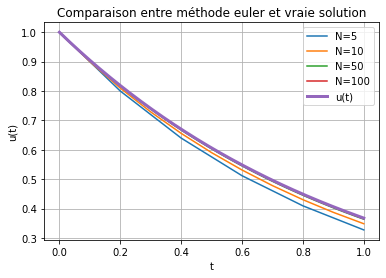

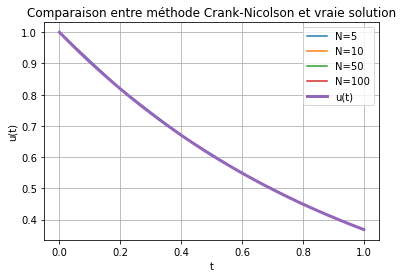

In [1]:
# Exercice 3 et 4 :

import numpy as np
import matplotlib.pyplot as plt

a = -1
T = 1
u_D = 1


def u(t):
    return u_D * np.exp(a * t)


def euler_method(N):
    h = T/N
    l1 = []
    l2 = []
    y_n = u_D #y0=u_D

    for n in range(N+1):
        t_n = n*h
        l1.append(t_n)
        l2.append(y_n)
        y_n = y_n + h*a*y_n   #t_{n+1}-t_{n}=h

    return l1, l2

def Crank_Nicolson_method(N):
    h = T/N
    l1 = []
    l2 = []
    y_n = u_D
    for n in range(0,N+1):
        t_n = n*h
        l1.append(t_n)
        l2.append(y_n)
        y_n = y_n * (2+a*h)/(2-a*h)
    return l1,l2


for N in [5, 10, 50, 100]:
    (l1,l2) = euler_method(N)
    plt.plot(l1, l2, label="N="+str(N))

x = np.linspace(0, T, 1000) #np.linspace(début,fin, pas = (fin-début)/(1000-1))
plt.plot(x, u(x), label="u(t)", linewidth=3)

plt.legend()
plt.grid(True)
plt.xlabel("t")
plt.ylabel("u(t)")
plt.title("Comparaison entre méthode euler et vraie solution")
plt.show()


for N in [5, 10, 50, 100]:
    (l1,l2) = Crank_Nicolson_method(N)
    plt.plot(l1, l2, label="N="+str(N))

x = np.linspace(0, T, 1000) 
plt.plot(x, u(x), label="u(t)", linewidth=3)

plt.legend()
plt.grid(True)
plt.xlabel("t")
plt.ylabel("u(t)")
plt.title("Comparaison entre méthode Crank-Nicolson et vraie solution")
plt.show()

Euler
0.04019944117144231
0.019201001071442347
0.0037097610843253026
0.0018470998982127451
Crank-Nicolson
0.0012316091182419386
0.00030689878857342867
1.2263179451188488e-05
3.065695217463471e-06


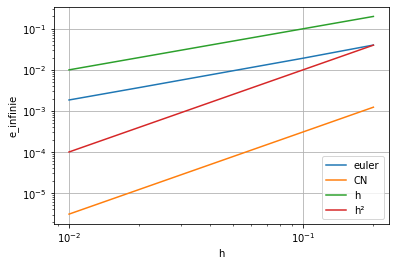

In [2]:
#Exercice 5 et 6 :


def Erreur_de_convergence(f_exacte, f_approx,N):
    (l1,l2) = f_approx(N)
    max = 0
    for n in range(0,N+1):
        if (np.abs(f_exacte(l1[n])-l2[n]))>max:
            max=np.abs(f_exacte(l1[n])-l2[n])
    return max


#Euler
erreur_euler = []
print("Euler")
for N in [5,10,50,100]:
    erreur_euler.append(Erreur_de_convergence(u,euler_method,N))
    print(Erreur_de_convergence(u,euler_method,N))

#Crank-Nicolson
erreur_crank_nicolson = []
print("Crank-Nicolson")
for N in [5,10,50,100]:
    erreur_crank_nicolson.append(Erreur_de_convergence(u,Crank_Nicolson_method,N))
    print(Erreur_de_convergence(u,Crank_Nicolson_method,N))


h= []
h2 = []
for N in [5,10,50,100]:
    h.append(T/N)
    h2.append((T/N)**2)

plt.loglog(h,erreur_euler, label = "euler")
plt.loglog(h,erreur_crank_nicolson, label ="CN")
plt.loglog(h,h, label = "h")
plt.loglog(h,h2, label = "h²")
plt.xlabel("h")
plt.ylabel("e_infinie")
plt.grid(True)
plt.legend()

#on voit alors que CN est d'ordre 2 tandis qu'euler est d'ordre 1



$e_\infty = max |e_n| = \max\limits_{1 \leq i \leq N} | u(t_n)-y_n|$

Exercice 7 : Montrons que $\max\limits_{0 \leq t_n \leq T} | u(t_n)-y_n| \leq CTh$

- Par la méthode d'Euler on a pour $0\leq n\leq N-1 $ : $\\\begin{aligned} y_{n+1} &= y_n + ha\times y_n\\&= y_n\times (1+ha)\\&=u_D\times (1+ah)^{n+1}\end{aligned}$ 

avec $y_0=u_D$ 

- On a $u(t_n)=u_De^{at_n}=u_De^{anh}$

Ainsi, $\max\limits_{0 \leq t_n \leq T} | u(t_n)-y_n| = \max\limits_{0 \leq t_n \leq T} | u_De^{anh} -u_D(1+ah)^{n} | = | u_D|\max\limits_{0 \leq t_n \leq T}  |e^{anh} -(1+ah)^{n} | $

- par le théorème de taylor young avec grand O : $$ \begin{aligned} e^{ah}&=1+ah+\frac{(ah)^2}{2}+O(h^3)\\\text{donc}\quad (1+ah)&=e^{ah}-\frac{(ah)^2}{2}-O(h^3)\\(1+ah)^n&=(e^{ah}-\frac{(ah)^2}{2}-O(h^3))^n\\(1+ah)^n&=e^{anh}(1-\frac{(ah)^2}{e^{ah}2}-\frac{O(h^3)}{e^{ah}})^n\end{aligned}$$


Or, posons $X=\frac{ah^2}{e^{ah}2}+\frac{O(h^3)}{e^{ah}}$

On a $$(1-X)^n=1-nX+O(X^2)$$ avec $X$ qui tend vers 0 car $h$ tend vers 0

Ainsi, $(1+ah)^n=e^{anh}(1-n\times (\frac{(ah)^2}{e^{ah}2}+\frac{O(h^3)}{e^{ah}})+O(h^2))=e^{anh}(1-n\times \frac{(ah)^2}{e^{ah}2}+O(h^2))$ car $O(h^3) \subset O(h^2)$ 

Or $$\begin{aligned} 0 &\le tn \le T\\ 0 &\le nh \le T \\ 0&\le n\le \frac{T}{h} = N\\ 0&\le nh^2\le Th\end{aligned}$$

et comme $Th$ domine $h²$ quand $h \to 0$, on a alors $|nh^2\times \frac{a^2}{e^{ah}2}+O(h^2)|=O(Th)$

Ainsi on a $| u_D|\max\limits_{0 \leq t_n \leq T}  |e^{anh} -(1+ah)^{n}| = | u_D|\max\limits_{0 \leq t_n \leq T}  |e^{anh}||1 -(1-O(Th))|\le| u_D|\max\limits_{0 \leq t_n \leq T}  |e^{aT}||1 -(1-O(Th))| =O(Th)$ en prenant $n=N$ à la dernière inégalité

Ainsi il existe une constante $C\gt 0$ tq $\max\limits_{0 \leq t_n \leq T} | u(t_n)-y_n| \leq CTh$ par définition du grand O




Exercice 8 : Par crank-nicolson on pour $0\leq n\leq N-1 $ : $$\begin{aligned} y_{n+1} = y_n \frac{1+\frac{ah}{2}}{1-\frac{ah}{2}}&=y_n \frac{2+ah}{2-ah} \\ &= y_{n-1} (\frac{2+ah}{2-ah})²\\ &=y_{n-n} (\frac{2+ah}{2-ah})^{n+1}\\&= u_D (\frac{2+ah}{2-ah})^{n+1}\end{aligned}$$

Montrons que $\max\limits_{0 \leq t_n \leq T} | u(t_n)-y_n| \leq CTh^2$ : 

On rappelle qu'on a $u(t_n)=u_De^{at_n}=u_De^{anh}$, montrons alors $|u_D| \max\limits_{0 \leq t_n \leq T} | e^{anh}- (\frac{2+ah}{2-ah})^n| \leq CTh$ 

Comme $ln(2+ah)=ln(2)+\frac{ah}{2}-\frac{(ah)²}{8}+O(h³)$ et $ln(2-ah)=ln(2)-\frac{ah}{2}-\frac{(ah)²}{8}+O(h³)$

donc $ln((\frac{2+ah}{2-ah})^n)=n\times (ln(2+ah)-ln(2-ah))=nah + nO(h³) = nah + O(Th²)$ car il existe une constante M tq $$\begin{aligned} O(h³)&<M|h³|\\n O(h³)&<nM|h³|\leq \frac{T}{h}M|h^3|\leq TM|h^2| \end{aligned}$$

Ainsi $|u_D| \max\limits_{0 \leq t_n \leq T} | e^{anh}- (\frac{2+ah}{2-ah})^n| = |u_D| \max\limits_{0 \leq t_n \leq T} | e^{anh}- e^{ahn + O(Th²)}| = |u_D| \max\limits_{0 \leq t_n \leq T} | e^{anh} | | 1 - e^{O(Th²)}| = |u_D| \max\limits_{0 \leq t_n \leq T} | e^{anh} | | 1 - (1+O(Th^2)+O((Th^2)^2))| \leq |u_De^{aT}O(Th^2)| = O(Th^2)$

Ainsi il existe C tq $\max\limits_{0 \leq t_n \leq T} | u(t_n)-y_n| \leq CTh^2$